## KUNWAR ASHWANI PRATAP SINGH
## BCADS 14
## 1250258250(11)
## BBDU

In [1]:
# ================================
# Netflix Data Analysis Assignment
# ================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("netflix.csv")


In [3]:
# Preview data
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [7]:
# Extract year and month
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


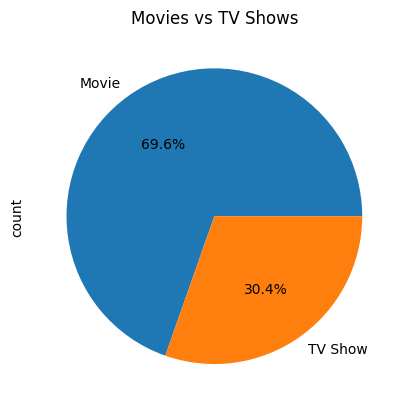

In [8]:
# Q1. Ratio of Movies vs TV Shows
type_counts = df['type'].value_counts()
print(type_counts)

type_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Movies vs TV Shows")
plt.show()

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


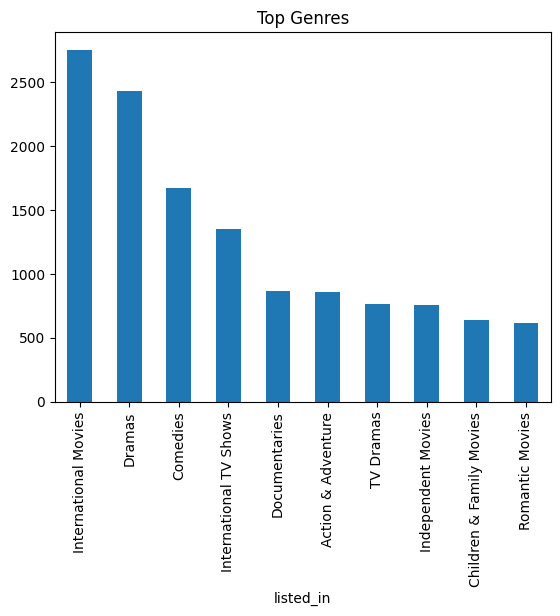

In [9]:
# Q2. Most popular genres globally
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
print(top_genres)

top_genres.plot(kind='bar')
plt.title("Top Genres")
plt.show()

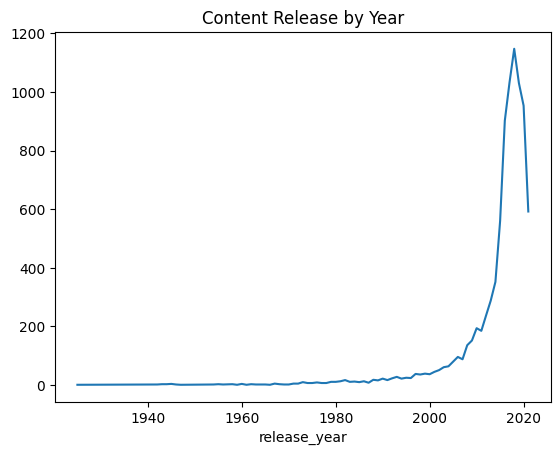

In [10]:
# Q3. Years with highest release content
release_year_counts = df['release_year'].value_counts().sort_index()
release_year_counts.plot()
plt.title("Content Release by Year")
plt.show()

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


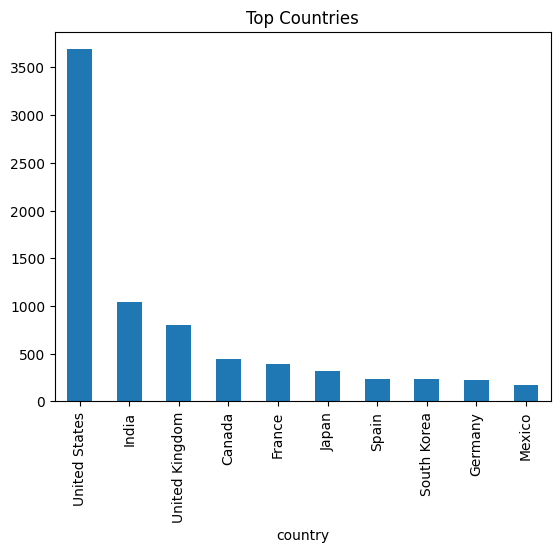

In [11]:
# Q4. Countries producing most content
countries = df['country'].str.split(', ').explode()
top_countries = countries.value_counts().head(10)
print(top_countries)

top_countries.plot(kind='bar')
plt.title("Top Countries")
plt.show()

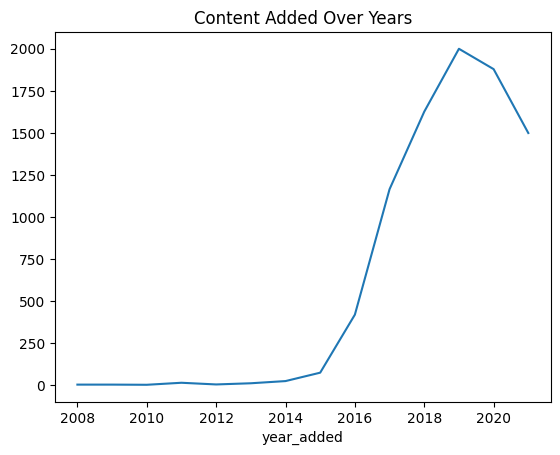

In [12]:
# Q5. Trend of adding content year by year
year_added_counts = df['year_added'].value_counts().sort_index()
year_added_counts.plot()
plt.title("Content Added Over Years")
plt.show()

## 2. User Demographics & Targeting

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


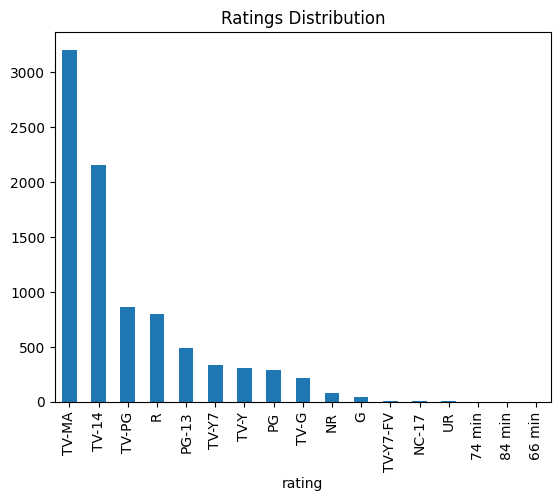

In [13]:
# Q6. Most frequent ratings
ratings = df['rating'].value_counts()
print(ratings)

ratings.plot(kind='bar')
plt.title("Ratings Distribution")
plt.show()

In [14]:
# Q7. Countries producing more TV-MA content
tv_ma = df[df['rating'] == 'TV-MA']
countries_tv_ma = tv_ma['country'].str.split(', ').explode().value_counts().head(10)
print(countries_tv_ma)

country
United States     1100
India              266
United Kingdom     251
Spain              170
France             163
Canada             107
Mexico             102
Japan              101
South Korea         92
Germany             79
Name: count, dtype: int64


In [15]:
# Q8. Genres associated with Movies vs TV Shows
genre_type = df.copy()
genre_type['listed_in'] = genre_type['listed_in'].str.split(', ')
genre_type = genre_type.explode('listed_in')

pd.crosstab(genre_type['listed_in'], genre_type['type']).head(10)

type,Movie,TV Show
listed_in,,
Action & Adventure,859,0
Anime Features,71,0
Anime Series,0,176
British TV Shows,0,253
Children & Family Movies,641,0
Classic & Cult TV,0,28
Classic Movies,116,0
Comedies,1674,0
Crime TV Shows,0,470


In [16]:
# Q9. Genres in US vs other countries
df['is_US'] = df['country'].str.contains('United States', na=False)

us_genres = df[df['is_US']]['listed_in'].str.split(', ').explode().value_counts().head(10)
non_us_genres = df[~df['is_US']]['listed_in'].str.split(', ').explode().value_counts().head(10)

print("US Genres:\n", us_genres)
print("\nNon-US Genres:\n", non_us_genres)

US Genres:
 listed_in
Dramas                      835
Comedies                    680
Documentaries               512
Action & Adventure          404
Children & Family Movies    390
Independent Movies          390
Thrillers                   292
TV Comedies                 258
TV Dramas                   232
Romantic Movies             225
Name: count, dtype: int64

Non-US Genres:
 listed_in
International Movies      2586
Dramas                    1592
International TV Shows    1277
Comedies                   994
TV Dramas                  531
Action & Adventure         455
Romantic Movies            391
Independent Movies         366
Documentaries              357
Romantic TV Shows          326
Name: count, dtype: int64


In [17]:
# Q10. Popular genres in last 3 years
recent = df[df['release_year'] >= df['release_year'].max() - 3]
recent_genres = recent['listed_in'].str.split(', ').explode().value_counts().head(10)
print(recent_genres)

listed_in
International Movies        1002
Dramas                       834
International TV Shows       754
Comedies                     540
TV Dramas                    452
Documentaries                354
TV Comedies                  334
Crime TV Shows               305
Children & Family Movies     274
Independent Movies           269
Name: count, dtype: int64


## 3. Talent Analysis

In [18]:
# Q11. Top 10 directors
directors = df['director'].str.split(', ').explode()
top_directors = directors.value_counts().head(10)
print(top_directors)

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64


In [19]:
# Q12. Most frequent actors
actors = df['cast'].str.split(', ').explode()
top_actors = actors.value_counts().head(10)
print(top_actors)

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Takahiro Sakurai    32
Naseeruddin Shah    32
Rupa Bhimani        31
Om Puri             30
Akshay Kumar        30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64


In [20]:
# Q13. Director-Genre pairs
df_pair = df.copy()
df_pair['listed_in'] = df_pair['listed_in'].str.split(', ')
df_pair = df_pair.explode('listed_in')

pairs = df_pair.groupby(['director', 'listed_in']).size().sort_values(ascending=False).head(10)
print(pairs)

director                listed_in               
Rajiv Chilaka           Children & Family Movies    19
Raúl Campos, Jan Suter  Stand-Up Comedy             18
Suhas Kadav             Children & Family Movies    16
Marcus Raboy            Stand-Up Comedy             15
Jay Karas               Stand-Up Comedy             13
Cathy Garcia-Molina     International Movies        13
Jay Chapman             Stand-Up Comedy             12
Youssef Chahine         Dramas                      12
                        International Movies        10
Martin Scorsese         Dramas                       9
dtype: int64


In [21]:
# Q14. Missing directors or cast
missing_director = df['director'].isna().sum()
missing_cast = df['cast'].isna().sum()

print("Missing Directors:", missing_director)
print("Missing Cast:", missing_cast)

Missing Directors: 2634
Missing Cast: 825


## 4. Duration & Engagement

In [24]:
# Q15. Average movie duration
movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min', '').astype(float)
print("Average Duration:", movies['duration'].mean())

Average Duration: 99.57718668407311


In [25]:
# Q16. Most common number of seasons
tv = df[df['type'] == 'TV Show'].copy()
tv['duration'] = tv['duration'].str.replace(' Seasons', '').str.replace(' Season', '')
print(tv['duration'].value_counts().head())

duration
1    1793
2     425
3     199
4      95
5      65
Name: count, dtype: int64


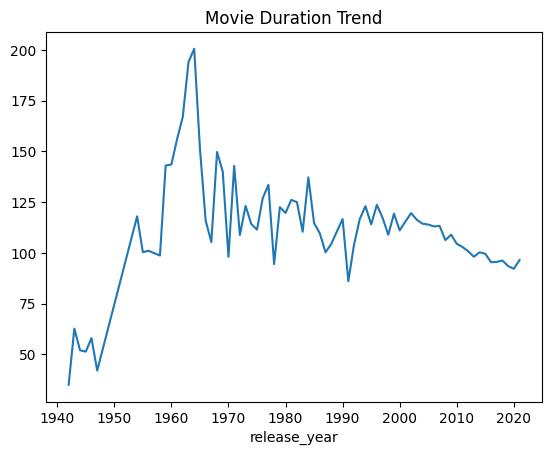

In [26]:
# Q17. Trend in movie duration over years
movies.groupby('release_year')['duration'].mean().plot()
plt.title("Movie Duration Trend")
plt.show()

## 5. Content Launch Strategy

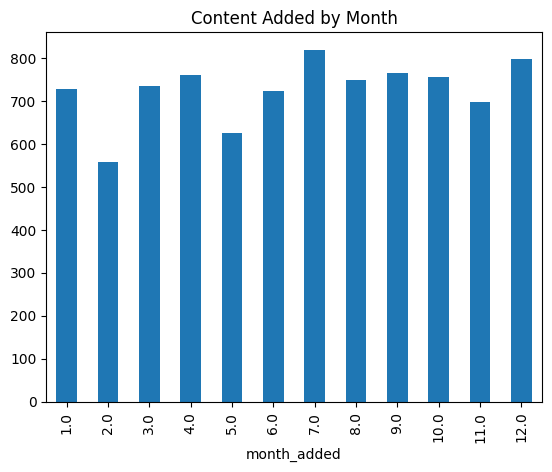

In [27]:
# Q18. Month with most content added
month_counts = df['month_added'].value_counts().sort_index()
month_counts.plot(kind='bar')
plt.title("Content Added by Month")
plt.show()

In [28]:
# Q19. Genre distribution over years
genre_year = df.copy()
genre_year['listed_in'] = genre_year['listed_in'].str.split(', ')
genre_year = genre_year.explode('listed_in')

genre_year.groupby(['release_year', 'listed_in']).size().unstack().fillna(0).tail()

listed_in,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
release_year,,,,,,,,,,,,,,,,,,,,,
2017,89.0,6.0,10.0,34.0,55.0,1.0,0.0,164.0,54.0,1.0,...,8.0,57.0,77.0,4.0,9.0,4.0,2.0,3.0,5.0,68.0
2018,81.0,8.0,24.0,37.0,69.0,2.0,1.0,178.0,79.0,1.0,...,28.0,82.0,109.0,11.0,15.0,7.0,0.0,7.0,8.0,83.0
2019,44.0,6.0,18.0,26.0,82.0,3.0,0.0,159.0,92.0,0.0,...,35.0,75.0,133.0,16.0,16.0,14.0,2.0,16.0,14.0,71.0
2020,46.0,3.0,21.0,33.0,83.0,3.0,0.0,133.0,87.0,0.0,...,32.0,105.0,127.0,17.0,27.0,19.0,2.0,7.0,11.0,45.0
2021,37.0,6.0,23.0,17.0,40.0,0.0,0.0,70.0,47.0,0.0,...,28.0,72.0,83.0,10.0,14.0,14.0,2.0,9.0,8.0,33.0


In [29]:
# Q20. Countries producing most content per genre
country_genre = df.copy()
country_genre['country'] = country_genre['country'].str.split(', ')
country_genre['listed_in'] = country_genre['listed_in'].str.split(', ')

country_genre = country_genre.explode('country').explode('listed_in')

result = country_genre.groupby(['country', 'listed_in']).size().sort_values(ascending=False).head(10)
print(result)

country        listed_in               
India          International Movies        864
United States  Dramas                      835
               Comedies                    680
India          Dramas                      662
United States  Documentaries               511
               Action & Adventure          404
               Independent Movies          390
               Children & Family Movies    390
India          Comedies                    323
United States  Thrillers                   292
dtype: int64


# ================================
# Final Insights
# ================================

# 1. Movies dominate Netflix content over TV Shows.
# 2. Drama and International genres are most popular.
# 3. USA and India are top content producers.
# 4. TV-MA rating is most frequent → adult audience focus.
# 5. Content addition peaked after 2016 → rapid growth phase.
# 6. Most movies are around 90–120 minutes.
# 7. Netflix adds most content in last quarter months (Oct–Dec).
# 8. Recent years show rise in international content.